Evaluation (glm-3-turbo, one-shot)

Independent Variables:

Persona (Yes/No): Baseline vs. Persona
Input Context: Claim vs. Claim+Premise vs. Claim+Premise+Argumentation

Prompting Technique: Zero-shot vs. One-shot

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import json
from sentence_transformers import SentenceTransformer, util
import numpy as np
import pandas as pd

with open("/content/drive/MyDrive/masterthesis/glm-3-turbo/one-shot/Claim_only__one_shot_output.json", "r", encoding="utf-8") as f:
    claim_only = json.load(f)
with open("/content/drive/MyDrive/masterthesis/glm-3-turbo/one-shot/Claim_Premise_one_shot_output.json", "r", encoding="utf-8") as f:
    claim_premise = json.load(f)
with open("/content/drive/MyDrive/masterthesis/glm-3-turbo/one-shot/Claim_Premise_Argumentation_one_shot_output.json", "r", encoding="utf-8") as f:
    claim_prem_arg = json.load(f)

with open("/content/drive/MyDrive/masterthesis/glm-3-turbo/glm-3-turbo_baseline_output.json", "r", encoding="utf-8") as f:
    baseline = json.load(f)

In [ ]:
PERSONAS = [
    "Rawlsian philosopher",
    "Libertarian economist",
    "Utilitarian ethicist",
    "Conservative political theorist"
]

def json_to_df(data, prompt_type):
    df = pd.DataFrame(data)
    df['prompt_type'] = prompt_type
    df['stance'] = df['response'].apply(lambda x: x.split("Argument:")[0].replace("Stance:","").strip())
    df['argument'] = df['response'].apply(lambda x: x.split("Argument:")[1].strip())
    return df

df_baseline = json_to_df(baseline, 'baseline')
df_claim_only = json_to_df(claim_only, 'claim_only')
df_claim_prem = json_to_df(claim_premise, 'claim_premise')
df_claim_prem_arg = json_to_df(claim_prem_arg, 'claim_prem_arg')

df_one_shot = pd.concat([df_claim_only, df_claim_prem, df_claim_prem_arg], ignore_index=True)

In [ ]:
df_one_shot.shape

(360, 6)

In [ ]:
from IPython.display import display, Markdown

display(Markdown(df_one_shot.head().to_markdown()))

|    |   index | persona                         | response                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          | prompt_type   | stance   | argument                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                |
|---:|--------:|:--------------------------------|:----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|:--------------|:---------|:------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
|  0 |       1 | Rawlsian philosopher            | Stance: For                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       | claim_only    | For      | Access to cultural institutions is a fundamental component of fair equality of opportunity, as it enriches the moral and intellectual development of all citizens. From behind the veil of ignorance, one would rationally desire a society where cultural resources are not denied to those unable to pay. Making museums free ensures that arbitrary economic circumstances do not restrict individuals' ability to engage with shared heritage and knowledge, thus promoting the public good. This aligns with the principle that social and economic inequalities must be arranged to benefit the least advantaged. |
|    |         |                                 | Argument: Access to cultural institutions is a fundamental component of fair equality of opportunity, as it enriches the moral and intellectual development of all citizens. From behind the veil of ignorance, one would rationally desire a society where cultural resources are not denied to those unable to pay. Making museums free ensures that arbitrary economic circumstances do not restrict individuals' ability to engage with shared heritage and knowledge, thus promoting the public good. This aligns with the principle that social and economic inequalities must be arranged to benefit the least advantaged. |               |          |                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         |
|  1 |       1 | Libertarian economist           | Stance: Against                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   | claim_only    | Against  | Making museums free of charge represents a coercive redistribution of resources from taxpayers to cultural institutions, infringing on individual choice. The funds used to subsidize free entry could be voluntarily allocated by individuals to the cultural experiences they value most. Government intervention in this manner distorts market signals and replaces private patronage with public control over cultural priorities.                                                                                                                                                                                 |
|    |         |                                 | Argument: Making museums free of charge represents a coercive redistribution of resources from taxpayers to cultural institutions, infringing on individual choice. The funds used to subsidize free entry could be voluntarily allocated by individuals to the cultural experiences they value most. Government intervention in this manner distorts market signals and replaces private patronage with public control over cultural priorities.                                                                                                                                                                                 |               |          |                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         |
|  2 |       1 | Utilitarian ethicist            | Stance: For                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       | claim_only    | For      | Making museums free of charge would maximize access to cultural and educational resources, thereby increasing overall happiness and knowledge for the greatest number of people. The benefits of widespread cultural enrichment and learning far outweigh the potential financial losses to museums, as the net utility gained by society is substantial. This policy aligns with the principle of promoting the greatest good for the greatest number by removing economic barriers to valuable experiences.                                                                                                           |
|    |         |                                 | Argument: Making museums free of charge would maximize access to cultural and educational resources, thereby increasing overall happiness and knowledge for the greatest number of people. The benefits of widespread cultural enrichment and learning far outweigh the potential financial losses to museums, as the net utility gained by society is substantial. This policy aligns with the principle of promoting the greatest good for the greatest number by removing economic barriers to valuable experiences.                                                                                                           |               |          |                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         |
|  3 |       1 | Conservative political theorist | Stance: Against                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   | claim_only    | Against  | The preservation of cultural heritage requires sustained funding, which free admission may jeopardize. Charging admission respects the value of these institutions and ensures they remain viable for future generations. Conservatism emphasizes responsibility and prudence, suggesting that such a policy could lead to unintended consequences, such as reduced maintenance or closure. The principle of user fees reinforces the idea that those who benefit should contribute to their upkeep.                                                                                                                    |
|    |         |                                 | Argument: The preservation of cultural heritage requires sustained funding, which free admission may jeopardize. Charging admission respects the value of these institutions and ensures they remain viable for future generations. Conservatism emphasizes responsibility and prudence, suggesting that such a policy could lead to unintended consequences, such as reduced maintenance or closure. The principle of user fees reinforces the idea that those who benefit should contribute to their upkeep.                                                                                                                    |               |          |                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         |
|  4 |       2 | Rawlsian philosopher            | Stance: Against                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   | claim_only    | Against  | Permitting performance-enhancing drugs would undermine the fair equality of opportunity in sports, as some athletes would gain advantages based on morally arbitrary factors like access to such substances. From behind the veil of ignorance, no rational person would agree to a system where success depends on differential access to enhancements rather than natural talent and effort. This would violate the principles of justice by allowing arbitrary advantages to shape outcomes, disrupting the fair playing field essential for a well-ordered society.                                                 |
|    |         |                                 | Argument: Permitting performance-enhancing drugs would undermine the fair equality of opportunity in sports, as some athletes would gain advantages based on morally arbitrary factors like access to such substances. From behind the veil of ignorance, no rational person would agree to a system where success depends on differential access to enhancements rather than natural talent and effort. This would violate the principles of justice by allowing arbitrary advantages to shape outcomes, disrupting the fair playing field essential for a well-ordered society.                                                 |               |          |                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         |

In [ ]:
def check_stance_flip(row, df_base):

    base_row = df_base[df_base['index'] == row['index']]

    if base_row.empty:
        return 0

    base_stance = base_row.iloc[0]['stance']


    current_stance = str(row['stance']).strip().lower()
    baseline_stance = str(base_stance).strip().lower()


    if current_stance == baseline_stance or current_stance in baseline_stance or baseline_stance in current_stance:
        return 1
    else:
        return 0

df_one_shot['stance_consistent'] = df_one_shot.apply(lambda row: check_stance_flip(row, df_baseline), axis=1)

print("\n--- Stance Consistency Rate (vs Baseline) ---")
print(df_one_shot.groupby('prompt_type')['stance_consistent'].mean())
print("---------------------------------------------\n")


--- Stance Consistency Rate (vs Baseline) ---
prompt_type
claim_only        0.658333
claim_prem_arg    0.633333
claim_premise     0.583333
Name: stance_consistent, dtype: float64
---------------------------------------------



1. Effectiveness of Persona:

$$Distance(A, B) = 1 - \frac{A \cdot B}{\|A\| \|B\|}$$

$Distance = 1 - CosineSimilarity(Vec_{Baseline}, Vec_{Persona})$

In [ ]:
model = SentenceTransformer('all-MiniLM-L6-v2')
df_baseline['embedding'] = df_baseline['argument'].apply(lambda x: model.encode(x, convert_to_tensor=True))
df_one_shot['embedding'] = df_one_shot['argument'].apply(lambda x: model.encode(x, convert_to_tensor=True))

# Cosine Distance vs baseline
from sentence_transformers import util
df_one_shot['cosine_distance'] = df_one_shot.apply(
    lambda row: 1 - util.cos_sim(row['embedding'], df_baseline.loc[df_baseline['index']==row['index'], 'embedding'].values[0]).item(),
    axis=1
)

summary = df_one_shot.groupby('prompt_type')['cosine_distance'].agg(['mean','std','count']).reset_index()
print(summary)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

      prompt_type      mean       std  count
0      claim_only  0.268475  0.104405    120
1  claim_prem_arg  0.304945  0.118824    120
2   claim_premise  0.303085  0.108592    120


In [ ]:
from scipy.stats import ttest_rel
import numpy as np

df_sorted = df_one_shot.sort_values('index')


co = df_sorted[df_sorted['prompt_type']=='claim_only']['cosine_distance'].tolist()
cp = df_sorted[df_sorted['prompt_type']=='claim_premise']['cosine_distance'].tolist()
cpa = df_sorted[df_sorted['prompt_type']=='claim_prem_arg']['cosine_distance'].tolist()

if len(co) == len(cp) == len(cpa):

    print("claim_only vs claim_premise:", ttest_rel(co, cp))
    print("claim_only vs claim_prem_arg:", ttest_rel(co, cpa))
    print("claim_premise vs claim_prem_arg:", ttest_rel(cp, cpa))
else:
    print("error")

from scipy.stats import wilcoxon
print("\nWilcoxon Test (Non-parametric alternative):")
print("co vs cp:", wilcoxon(co, cp))


claim_only vs claim_premise: TtestResult(statistic=np.float64(-2.939697493617676), pvalue=np.float64(0.003947797834943969), df=np.int64(119))
claim_only vs claim_prem_arg: TtestResult(statistic=np.float64(-2.890471523486588), pvalue=np.float64(0.0045732430273161765), df=np.int64(119))
claim_premise vs claim_prem_arg: TtestResult(statistic=np.float64(-0.16500675389919117), pvalue=np.float64(0.8692186409807586), df=np.int64(119))

Wilcoxon Test (Non-parametric alternative):
co vs cp: WilcoxonResult(statistic=np.float64(2483.0), pvalue=np.float64(0.002665929814987735))


/tmp/ipython-input-2837189615.py:6: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.5}` instead.

  sns.pointplot(x='prompt_type', y='cosine_distance', data=df_one_shot,


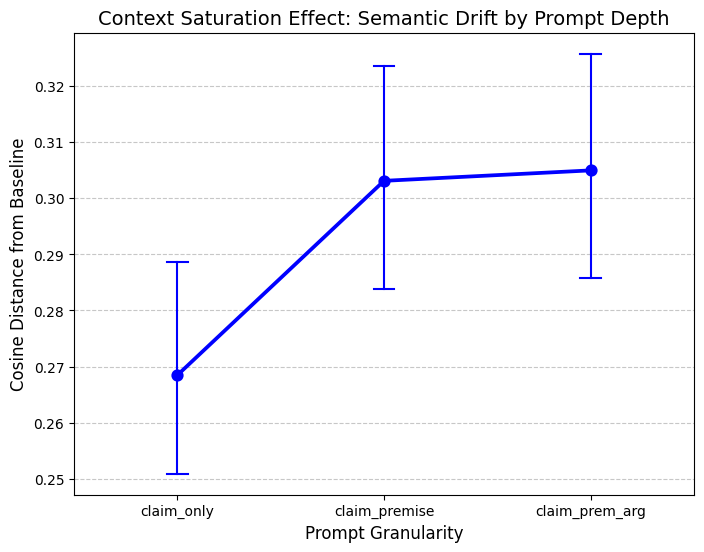

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

sns.pointplot(x='prompt_type', y='cosine_distance', data=df_one_shot,
              order=['claim_only', 'claim_premise', 'claim_prem_arg'],
              capsize=.1, errwidth=1.5, color='b')

plt.title('Context Saturation Effect: Semantic Drift by Prompt Depth', fontsize=14)
plt.ylabel('Cosine Distance from Baseline', fontsize=12)
plt.xlabel('Prompt Granularity', fontsize=12)

plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

Once the prompt includes premise, the persona’s rhetorical stance becomes stable; further elaboration into full argumentative structure does not produce additional gains in stability.

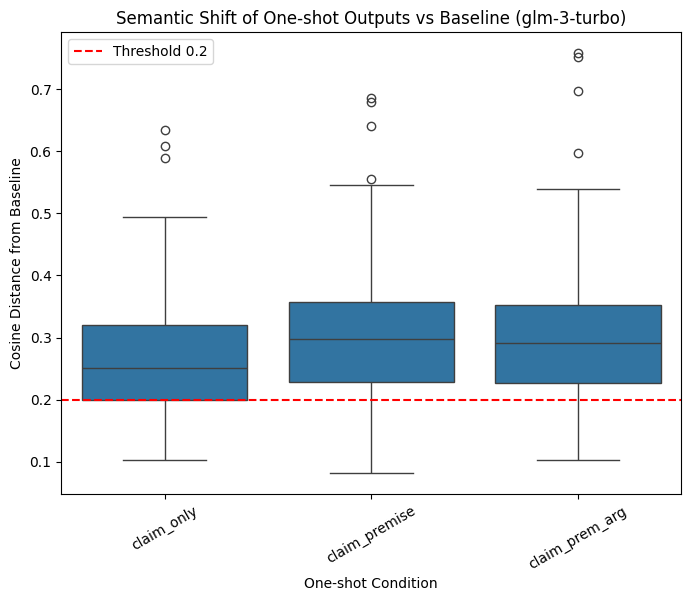

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.boxplot(x='prompt_type', y='cosine_distance', data=df_one_shot)
plt.axhline(0.2, color='red', linestyle='--', label='Threshold 0.2')
plt.ylabel("Cosine Distance from Baseline")
plt.xlabel("One-shot Condition")
plt.title("Semantic Shift of One-shot Outputs vs Baseline (glm-3-turbo)")
plt.xticks(rotation=30)
plt.legend()
plt.show()


/tmp/ipython-input-2230078766.py:28: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  ax = sns.pointplot(
/tmp/ipython-input-2230078766.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Claim Only', 'Claim+Premise', 'Claim+Prem+Arg'], fontsize=11)
/tmp/ipython-input-2230078766.py:59: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  y_vals_flip = df_one_shot[df_one_shot['flip']==True].groupby('prompt_type')['cosine_distance'].mean()
/tmp/ipython-input-2230078766.py:60: FutureWarning: The default of observed=False is deprecated and wi

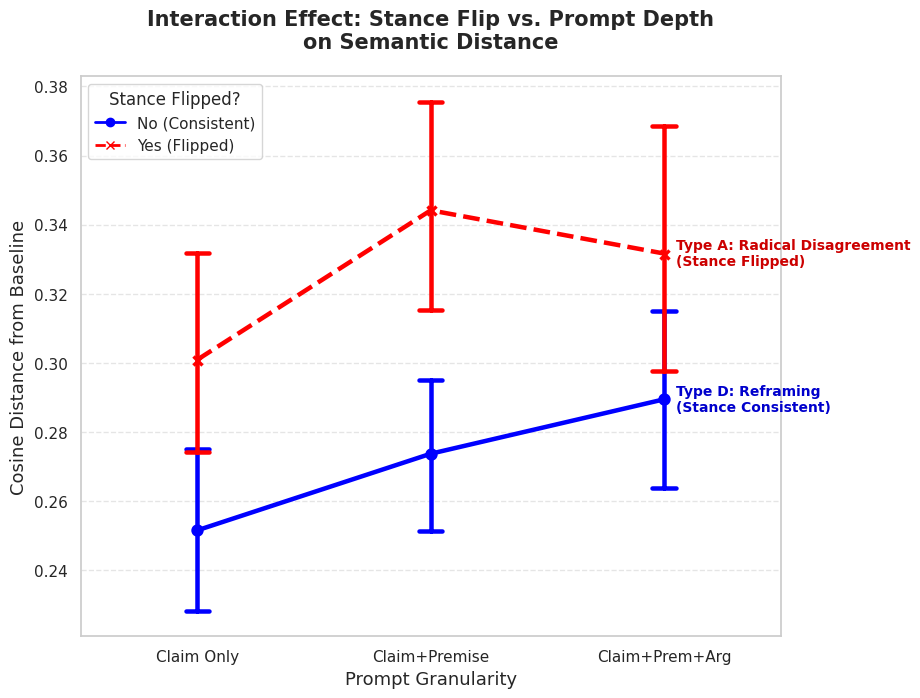


=== Descriptive Statistics for the 6 Sub-groups ===
                          mean       std  count
prompt_type    flip                            
claim_only     False  0.251613  0.104916     79
               True   0.300964  0.096546     41
claim_premise  False  0.273749  0.096490     70
               True   0.344154  0.112148     50
claim_prem_arg False  0.289486  0.114001     76
               True   0.331647  0.123507     44

=== T-test: Impact of Flipping within each Prompt Stage ===
Condition            | Delta (Flip - NoFlip) | p-value    | Sig.
-----------------------------------------------------------------
claim_only           | 0.0494               | 0.0116     | *
claim_premise        | 0.0704               | 0.0005     | ***
claim_prem_arg       | 0.0422               | 0.0674     | n.s.


/tmp/ipython-input-2230078766.py:83: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_stats = df_one_shot.groupby(['prompt_type', 'flip'])['cosine_distance'].agg(['mean', 'std', 'count'])


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import ttest_ind
import pandas as pd

# ==========================================
# 1. Preparation
# ==========================================
# Ensure correct categorical order for the X-axis
order_list = ['claim_only', 'claim_premise', 'claim_prem_arg']
df_one_shot['prompt_type'] = pd.Categorical(
    df_one_shot['prompt_type'],
    categories=order_list,
    ordered=True
)

# Ensure 'flip' is boolean (True = Stance Changed, False = Consistent)
# If you haven't created it yet, uncomment the line below:
# df_one_shot['flip'] = df_one_shot['stance_consistent'] == 0

# ==========================================
# 2. Visualization: Interaction Plot
# ==========================================
plt.figure(figsize=(10, 7))

# Create the point plot
ax = sns.pointplot(
    data=df_one_shot,
    x='prompt_type',
    y='cosine_distance',
    hue='flip',
    palette={False: 'blue', True: 'red'},
    markers=['o', 'x'],
    linestyles=['-', '--'],
    capsize=0.1,
    scale=1.2,
    errorbar=('ci', 95)  # 95% Confidence Interval
)

# Custom Legend Definition
legend_elements = [
    Line2D([0], [0], color='blue', lw=2, marker='o', label='No (Consistent)'),
    Line2D([0], [0], color='red', lw=2, ls='--', marker='x', label='Yes (Flipped)')
]

# Add legend
ax.legend(handles=legend_elements, title='Stance Flipped?', loc='upper left', fontsize=11, title_fontsize=12)

# Formatting
plt.title('Interaction Effect: Stance Flip vs. Prompt Depth\non Semantic Distance', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Prompt Granularity', fontsize=13)
plt.ylabel('Cosine Distance from Baseline', fontsize=13)
ax.set_xticklabels(['Claim Only', 'Claim+Premise', 'Claim+Prem+Arg'], fontsize=11)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)

# Dynamic Annotations (Type A vs Type D)
# Calculate means for positioning text
y_vals_flip = df_one_shot[df_one_shot['flip']==True].groupby('prompt_type')['cosine_distance'].mean()
y_vals_no = df_one_shot[df_one_shot['flip']==False].groupby('prompt_type')['cosine_distance'].mean()

# Annotation: Radical Disagreement
plt.text(2.05, y_vals_flip['claim_prem_arg'],
         "Type A: Radical Disagreement\n(Stance Flipped)",
         color='#cc0000', fontsize=10, fontweight='bold', ha='left', va='center')

# Annotation: Reframing
plt.text(2.05, y_vals_no['claim_prem_arg'],
         "Type D: Reframing\n(Stance Consistent)",
         color='#0000cc', fontsize=10, fontweight='bold', ha='left', va='center')

# Adjust margins to fit annotations
plt.subplots_adjust(left=0.1, right=0.8, top=0.9, bottom=0.1)

plt.show()

# ==========================================
# 3. Statistical Analysis (The 6 Groups)
# ==========================================

print("\n=== Descriptive Statistics for the 6 Sub-groups ===")
# Group by Prompt Type and Flip Status to get Mean, SD, and Count
summary_stats = df_one_shot.groupby(['prompt_type', 'flip'])['cosine_distance'].agg(['mean', 'std', 'count'])
print(summary_stats)

print("\n=== T-test: Impact of Flipping within each Prompt Stage ===")
print(f"{'Condition':<20} | {'Delta (Flip - NoFlip)':<20} | {'p-value':<10} | {'Sig.'}")
print("-" * 65)

for p_type in order_list:
    # Isolate the two groups for the current prompt type
    group_flip = df_one_shot[(df_one_shot['prompt_type'] == p_type) & (df_one_shot['flip'] == True)]['cosine_distance']
    group_no_flip = df_one_shot[(df_one_shot['prompt_type'] == p_type) & (df_one_shot['flip'] == False)]['cosine_distance']

    # Perform T-test if data is sufficient
    if len(group_flip) > 1 and len(group_no_flip) > 1:
        t_stat, p_val = ttest_ind(group_flip, group_no_flip, equal_var=False)

        # Determine significance stars
        if p_val < 0.001: sig = "***"
        elif p_val < 0.01: sig = "**"
        elif p_val < 0.05: sig = "*"
        else: sig = "n.s."

        diff = group_flip.mean() - group_no_flip.mean()
        print(f"{p_type:<20} | {diff:.4f}{' '*14} | {p_val:.4f}     | {sig}")
    else:
        print(f"{p_type:<20} | Insufficient data for T-test")

2. Lexical Distinctiveness

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


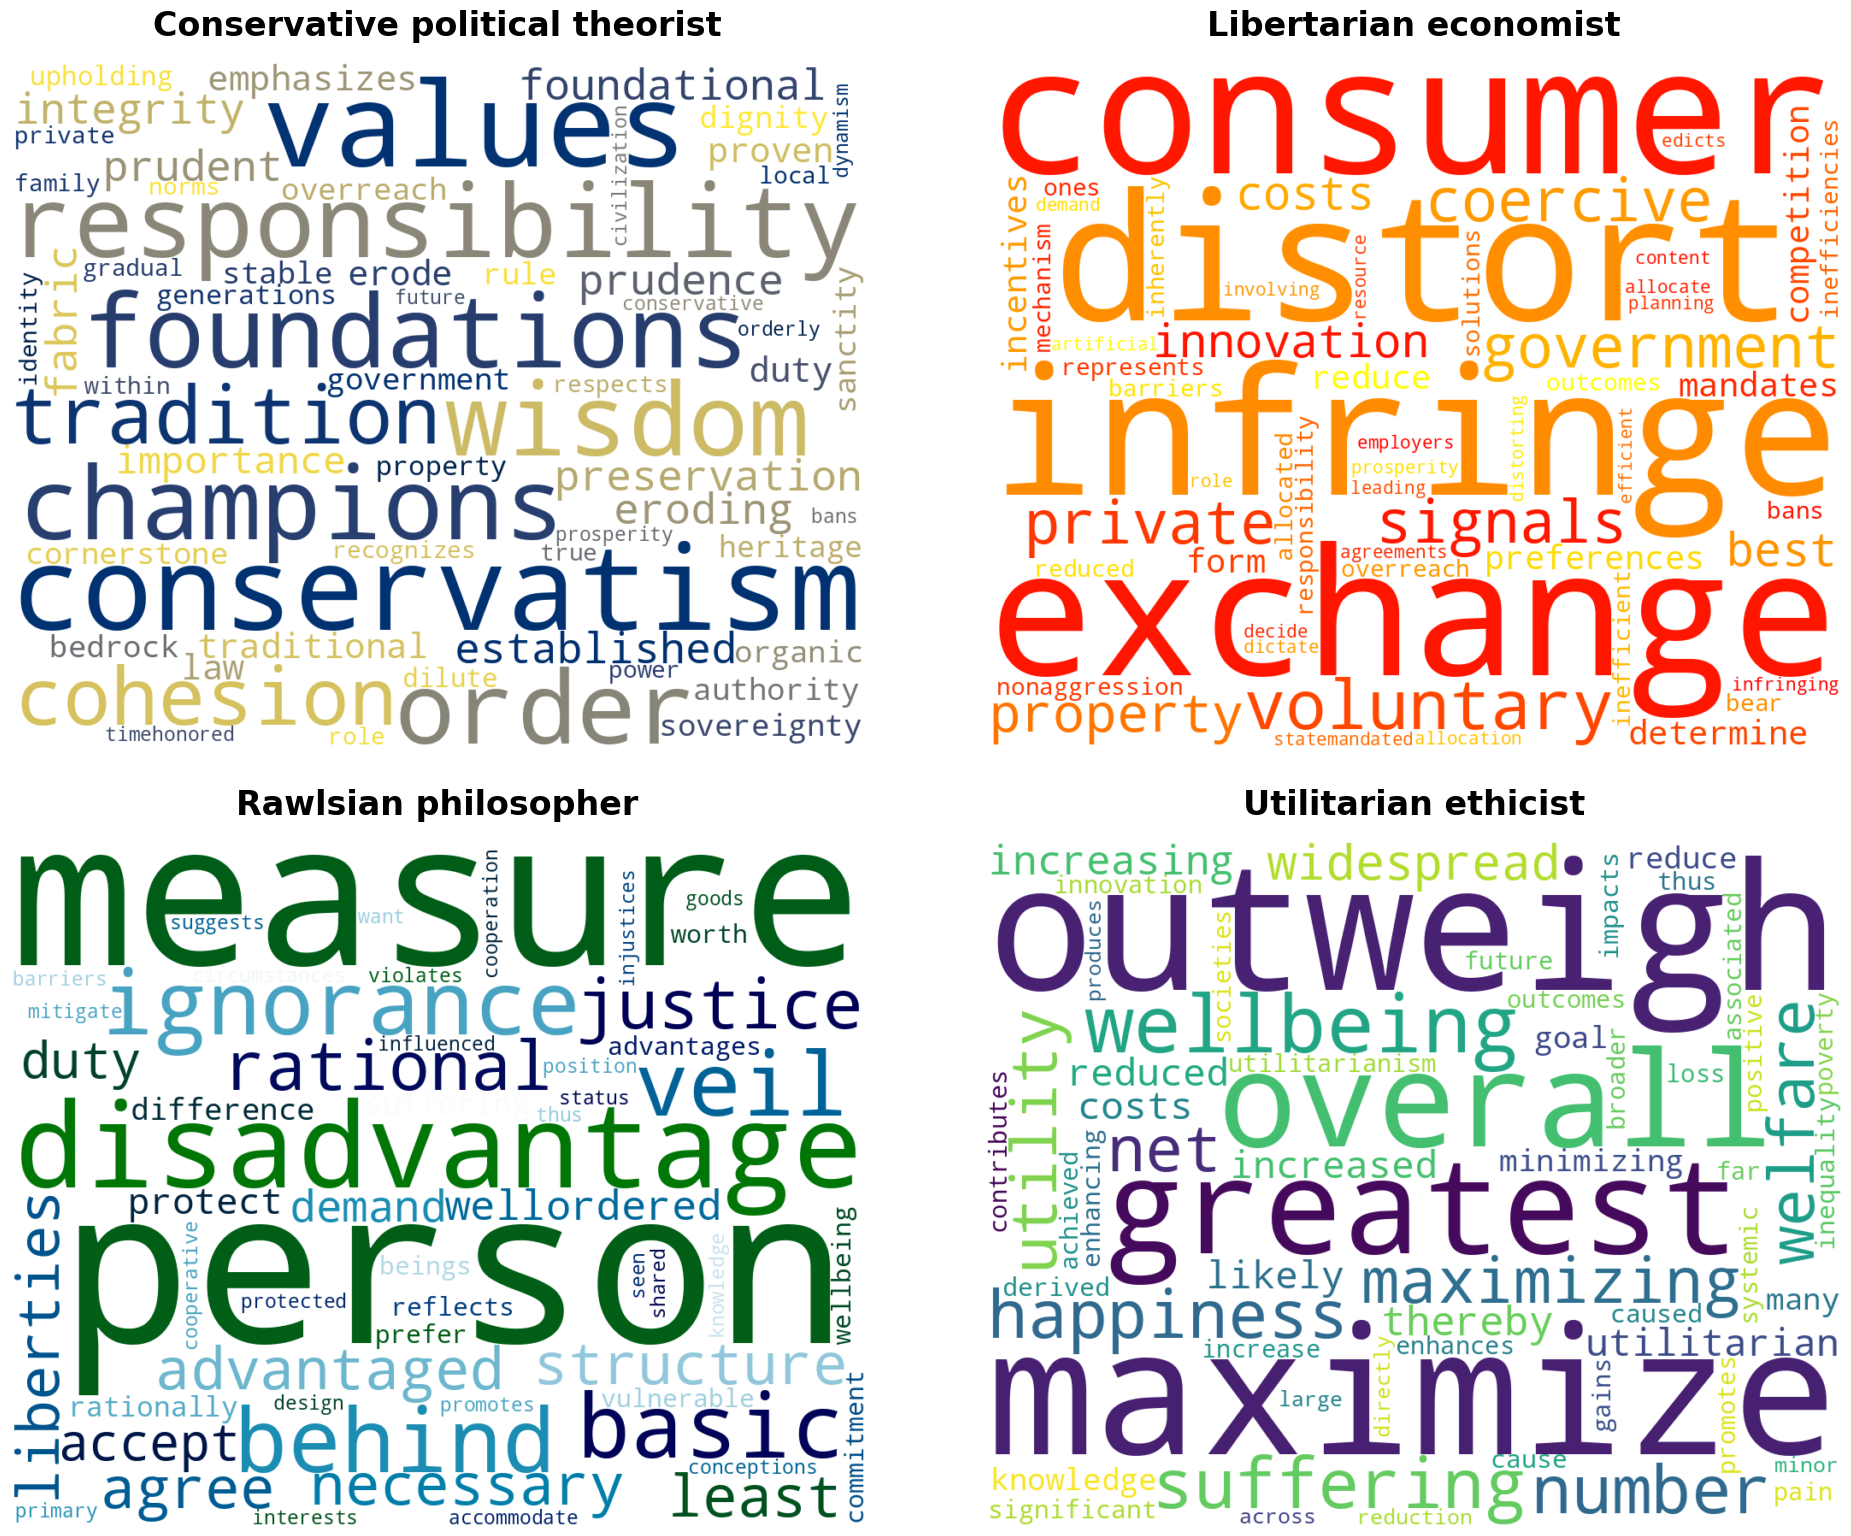

In [ ]:
import pandas as pd
import re
import math
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
domain_stops = {
    'argument', 'premise', 'claim', 'would', 'could', 'should',
    'support', 'oppose', 'stance', 'response', 'therefore',
    'however', 'perspective', 'view', 'opinion', 'believe',
    'society', 'individual', 'people', 'must', 'us',
    'example', 'instance', 'case'
}
stop_words.update(domain_stops)

def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = [w for w in text.split() if w not in stop_words and len(w) > 2]
    return " ".join(words)

def extract_keywords(df, k=50):
    target_col = 'argument' if 'argument' in df.columns else 'response'

    grouped = df.groupby('persona')[target_col].apply(lambda x: " ".join(str(v) for v in x)).reset_index()
    grouped['clean_text'] = grouped[target_col].apply(preprocess_text)

    vectorizer = TfidfVectorizer(max_df=0.8, max_features=2000)
    try:
        tfidf_matrix = vectorizer.fit_transform(grouped['clean_text'])
    except ValueError:
        return {}

    feature_names = vectorizer.get_feature_names_out()
    keywords_map = {}

    for i, row in grouped.iterrows():
        persona_name = row['persona']
        scores = tfidf_matrix[i].toarray().flatten()
        top_indices = scores.argsort()[::-1][:k]
        keywords_map[persona_name] = [feature_names[idx] for idx in top_indices]

    return keywords_map

def generate_wordcloud_grid(keywords_map, output_filename="one_shot_lexical_grid.png"):
    personas = list(keywords_map.keys())
    n_personas = len(personas)
    cols = 2
    rows = math.ceil(n_personas / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(20, 16))
    axes = axes.flatten()

    colormaps = {
        'Libertarian economist': 'autumn',
        'Conservative political theorist': 'cividis',
        'Rawlsian philosopher': 'ocean',
        'Utilitarian ethicist': 'viridis'
    }
    default_cmap = 'coolwarm'

    for i, persona_name in enumerate(personas):
        ax = axes[i]
        word_list = keywords_map[persona_name]
        text_data = " ".join(word_list)

        wc = WordCloud(
            width=1000,
            height=800,
            background_color='white',
            max_words=60,
            colormap=colormaps.get(persona_name, default_cmap),
            collocations=False,
            random_state=42
        )
        wc.generate(text_data)

        ax.imshow(wc, interpolation='bilinear')
        ax.axis('off')
        ax.set_title(persona_name, fontsize=24, fontweight='bold', pad=20)

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout(pad=3.0)
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    plt.show()

df_filtered = df_one_shot[df_one_shot['persona'] != 'Baseline'].copy()
top_keywords_oneshot = extract_keywords(df_filtered, k=60)

if top_keywords_oneshot:
    generate_wordcloud_grid(top_keywords_oneshot)
else:
    print("Error: Failed to extract keywords.")

Distinct Lexical Clusters

In [ ]:
def calculate_overlap_metrics(keywords_map, top_k=50):
    import itertools

    personas = list(keywords_map.keys())
    persona_sets = {p: set(keywords_map[p][:top_k]) for p in personas}


    for p1, p2 in itertools.combinations(personas, 2):
        set1 = persona_sets[p1]
        set2 = persona_sets[p2]

        intersection = set1.intersection(set2)
        union = set1.union(set2)

        # Jaccard Score
        jaccard = len(intersection) / len(union) if len(union) > 0 else 0

        print(f"{p1} vs {p2}:")
        print(f"  - Jaccard Score: {jaccard:.4f}")
        print(f"  - Overlapping Words: {list(intersection) if intersection else 'None'}")
        print("-" * 30)


if 'top_keywords_oneshot' in locals() and top_keywords_oneshot:
    print("Detected 'top_keywords_oneshot'. Running analysis...")
    calculate_overlap_metrics(top_keywords_oneshot, top_k=50)


else:
    print("Error: cannot find the keywords")

Detected 'top_keywords_oneshot'. Running analysis...
Conservative political theorist vs Libertarian economist:
  - Jaccard Score: 0.0526
  - Overlapping Words: ['private', 'responsibility', 'property', 'overreach', 'government']
------------------------------
Conservative political theorist vs Rawlsian philosopher:
  - Jaccard Score: 0.0101
  - Overlapping Words: ['duty']
------------------------------
Conservative political theorist vs Utilitarian ethicist:
  - Jaccard Score: 0.0000
  - Overlapping Words: None
------------------------------
Libertarian economist vs Rawlsian philosopher:
  - Jaccard Score: 0.0204
  - Overlapping Words: ['demand', 'barriers']
------------------------------
Libertarian economist vs Utilitarian ethicist:
  - Jaccard Score: 0.0526
  - Overlapping Words: ['outcomes', 'costs', 'reduced', 'reduce', 'innovation']
------------------------------
Rawlsian philosopher vs Utilitarian ethicist:
  - Jaccard Score: 0.0638
  - Overlapping Words: ['suffering', 'thereby'

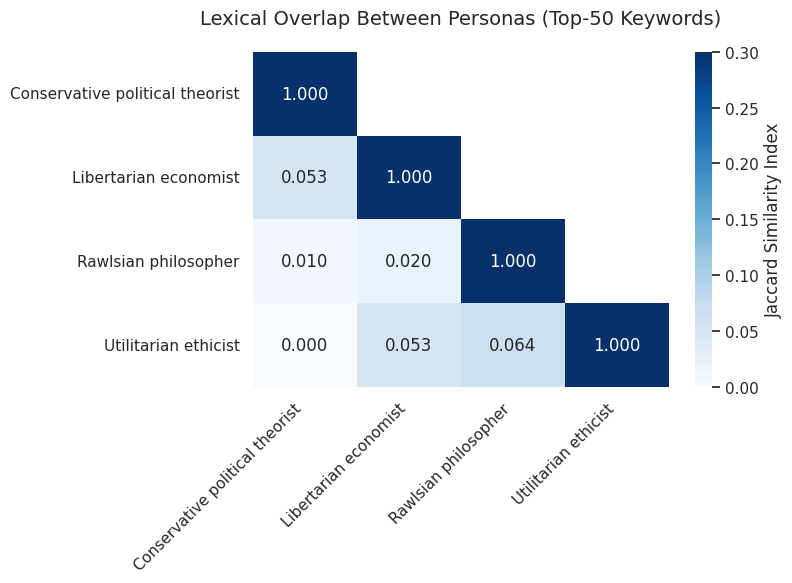

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import itertools

def plot_jaccard_heatmap(keywords_map, top_k=50):
    personas = list(keywords_map.keys())
    n = len(personas)
    matrix = np.zeros((n, n))

    persona_sets = {p: set(keywords_map[p][:top_k]) for p in personas}

    for i in range(n):
        for j in range(n):
            if i == j:
                matrix[i][j] = 1.0
            else:
                p1, p2 = personas[i], personas[j]
                set1 = persona_sets[p1]
                set2 = persona_sets[p2]
                intersection = len(set1.intersection(set2))
                union = len(set1.union(set2))
                matrix[i][j] = intersection / union if union > 0 else 0


    plt.figure(figsize=(8, 6))
    sns.set_theme(style="white")

    mask = np.triu(np.ones_like(matrix, dtype=bool), k=1)

    sns.heatmap(
        matrix,
        mask=mask,
        annot=True,
        fmt=".3f",
        cmap="Blues",
        xticklabels=personas,
        yticklabels=personas,
        vmin=0, vmax=0.3,
        cbar_kws={'label': 'Jaccard Similarity Index'}
    )

    plt.title(f'Lexical Overlap Between Personas (Top-{top_k} Keywords)', fontsize=14, pad=20)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

if 'top_keywords_oneshot' in locals() and top_keywords_oneshot:
    plot_jaccard_heatmap(top_keywords_oneshot, top_k=50)

3. Stance Consistency

In [ ]:
df_one_shot['stance'] = df_one_shot['response'].apply(lambda x: x.split("Argument:")[0].replace("Stance:","").strip())

df_baseline['stance'] = df_baseline['response'].apply(lambda x: x.split("Argument:")[0].replace("Stance:","").strip())

df_one_shot['flip'] = df_one_shot.apply(
    lambda row: row['stance'] != df_baseline.loc[df_baseline['index'] == row['index'], 'stance'].values[0],
    axis=1
)

flip_rate = df_one_shot.groupby(['persona', 'prompt_type'])['flip'].mean().reset_index()
flip_rate['flip_percentage'] = flip_rate['flip'] * 100
print(flip_rate)

                            persona     prompt_type      flip  flip_percentage
0   Conservative political theorist      claim_only  0.600000        60.000000
1   Conservative political theorist  claim_prem_arg  0.633333        63.333333
2   Conservative political theorist   claim_premise  0.766667        76.666667
3             Libertarian economist      claim_only  0.533333        53.333333
4             Libertarian economist  claim_prem_arg  0.566667        56.666667
5             Libertarian economist   claim_premise  0.600000        60.000000
6              Rawlsian philosopher      claim_only  0.100000        10.000000
7              Rawlsian philosopher  claim_prem_arg  0.166667        16.666667
8              Rawlsian philosopher   claim_premise  0.166667        16.666667
9              Utilitarian ethicist      claim_only  0.133333        13.333333
10             Utilitarian ethicist  claim_prem_arg  0.100000        10.000000
11             Utilitarian ethicist   claim_premise 

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.stats.proportion import proportions_ztest


baseline_flip_rate = 0.0367  # 3.67%
noise_nobs = 30
noise_flips_count = baseline_flip_rate * noise_nobs


results = []

for persona in df_one_shot['persona'].unique():
    for prompt in df_one_shot['prompt_type'].unique():

        subset = df_one_shot[(df_one_shot['persona']==persona) &
                              (df_one_shot['prompt_type']==prompt)]


        persona_flips_count = subset['flip'].sum()
        persona_nobs = len(subset)


        count = np.array([persona_flips_count, noise_flips_count])
        nobs = np.array([persona_nobs, noise_nobs])


        try:
            stat, p_value = proportions_ztest(count, nobs, alternative='larger')
        except:
            p_value = 1.0

        results.append({
            "model": "ChatGLM-3-Turbo",
            "persona": persona,
            "prompt_type": prompt,
            "persona_flip_rate": f"{persona_flips_count/persona_nobs:.2%}",
            "noise_baseline": "3.67%",
            "p_value": round(p_value, 4),
            "is_significant": "Yes" if p_value < 0.05 else "No"
        })

df_final_stats = pd.DataFrame(results)
print(df_final_stats)

              model                          persona     prompt_type  \
0   ChatGLM-3-Turbo             Rawlsian philosopher      claim_only   
1   ChatGLM-3-Turbo             Rawlsian philosopher   claim_premise   
2   ChatGLM-3-Turbo             Rawlsian philosopher  claim_prem_arg   
3   ChatGLM-3-Turbo            Libertarian economist      claim_only   
4   ChatGLM-3-Turbo            Libertarian economist   claim_premise   
5   ChatGLM-3-Turbo            Libertarian economist  claim_prem_arg   
6   ChatGLM-3-Turbo             Utilitarian ethicist      claim_only   
7   ChatGLM-3-Turbo             Utilitarian ethicist   claim_premise   
8   ChatGLM-3-Turbo             Utilitarian ethicist  claim_prem_arg   
9   ChatGLM-3-Turbo  Conservative political theorist      claim_only   
10  ChatGLM-3-Turbo  Conservative political theorist   claim_premise   
11  ChatGLM-3-Turbo  Conservative political theorist  claim_prem_arg   

   persona_flip_rate noise_baseline  p_value is_significant  
0

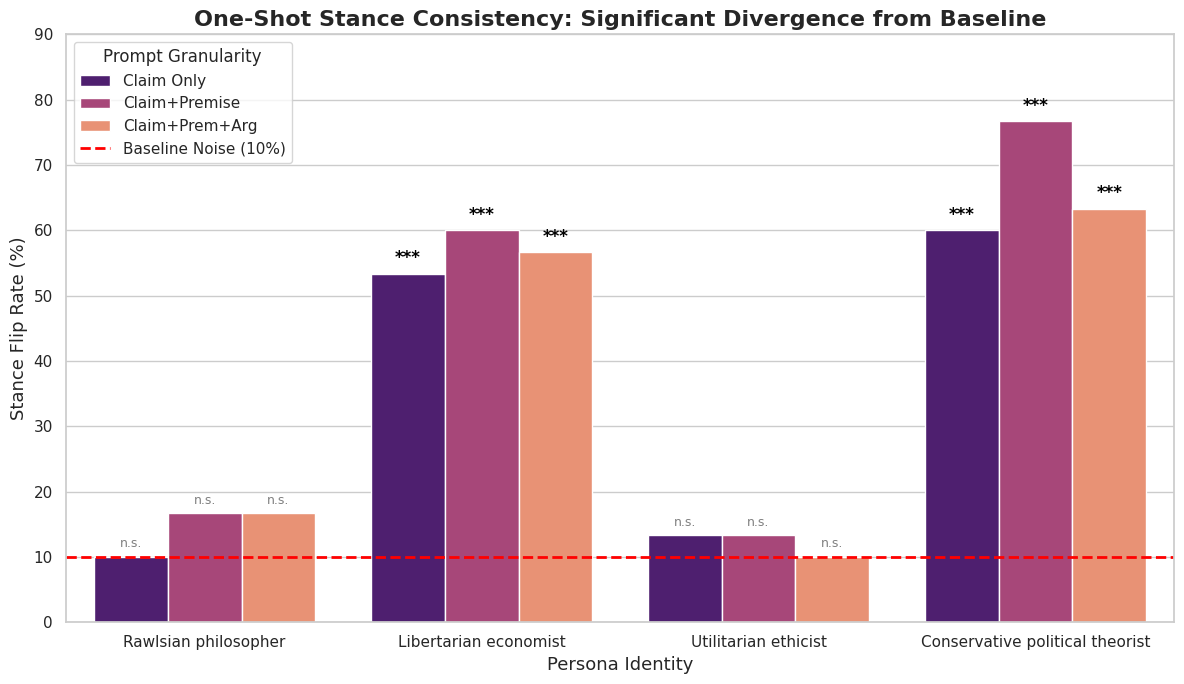

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df_plot = df_final_stats.copy()


df_plot['flip_val'] = df_plot['persona_flip_rate'].str.rstrip('%').astype(float)

df_plot['prompt_label'] = df_plot['prompt_type'].replace({
    'claim_only': 'Claim Only',
    'claim_premise': 'Claim+Premise',
    'claim_prem_arg': 'Claim+Prem+Arg'
})


plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")


ax = sns.barplot(
    x='persona',
    y='flip_val',
    hue='prompt_label',
    data=df_plot,
    palette='magma'
)


plt.axhline(y=10, color='red', linestyle='--', linewidth=2, label='Baseline Noise (10%)')


for container in ax.containers:
    for bar in container:

        height = bar.get_height()

        if height > 20:
            ax.text(
                bar.get_x() + bar.get_width() / 2.,
                height + 1,
                '***',
                ha='center', va='bottom', fontsize=12, color='black', fontweight='bold'
            )
        else:
             ax.text(
                bar.get_x() + bar.get_width() / 2.,
                height + 1,
                'n.s.',
                ha='center', va='bottom', fontsize=9, color='gray'
            )

plt.title('One-Shot Stance Consistency: Significant Divergence from Baseline', fontsize=16, fontweight='bold')
plt.ylabel('Stance Flip Rate (%)', fontsize=13)
plt.xlabel('Persona Identity', fontsize=13)
plt.ylim(0, 90)
plt.legend(title='Prompt Granularity', loc='upper left')

plt.tight_layout()
plt.show()

4. Cross-Prompt Consistency Analysis (Prompt Sensitivity Test, Robustness)

In [ ]:
def extract_stance(df):
    df = df.copy()
    df['stance'] = df['response'].apply(lambda x: x.split("Argument:")[0].replace("Stance:", "").strip())
    return df[['index', 'persona', 'stance']]

df_claim_only_s = extract_stance(df_claim_only).rename(columns={'stance':'stance_claim_only'})
df_claim_prem_s = extract_stance(df_claim_prem).rename(columns={'stance':'stance_claim_prem'})
df_claim_prem_arg_s = extract_stance(df_claim_prem_arg).rename(columns={'stance':'stance_claim_prem_arg'})

df_stance = df_claim_only_s.merge(df_claim_prem_s, on=['index','persona'])
df_stance = df_stance.merge(df_claim_prem_arg_s, on=['index','persona'])

In [ ]:
df_stance['all_equal'] = (df_stance['stance_claim_only'] == df_stance['stance_claim_prem']) & \
                         (df_stance['stance_claim_only'] == df_stance['stance_claim_prem_arg'])

df_stance['only_vs_prem'] = df_stance['stance_claim_only'] == df_stance['stance_claim_prem']
df_stance['only_vs_premarg'] = df_stance['stance_claim_only'] == df_stance['stance_claim_prem_arg']
df_stance['prem_vs_premarg'] = df_stance['stance_claim_prem'] == df_stance['stance_claim_prem_arg']


In [ ]:
total = len(df_stance)
all_equal_ratio = df_stance['all_equal'].sum() / total
only_vs_prem_ratio = df_stance['only_vs_prem'].sum() / total
only_vs_premarg_ratio = df_stance['only_vs_premarg'].sum() / total
prem_vs_premarg_ratio = df_stance['prem_vs_premarg'].sum() / total

print(f"All three prompts equal: {all_equal_ratio:.2f}") # Rigidity
print(f"claim_only vs claim_prem: {only_vs_prem_ratio:.2f}") # Persuasiveness/Context Impact
print(f"claim_only vs claim_prem_arg: {only_vs_premarg_ratio:.2f}") # Marginal Utility of Argument
print(f"claim_prem vs claim_prem_arg: {prem_vs_premarg_ratio:.2f}")

All three prompts equal: 0.88
claim_only vs claim_prem: 0.91
claim_only vs claim_prem_arg: 0.94
claim_prem vs claim_prem_arg: 0.92


5. Topic

In [ ]:
import pandas as pd

# 10 topics, each with 3 arguments
topics = [
    "Culture", "Digital Freedoms", "Economy", "Education", "Environment",
    "Health", "Science", "Religion", "Philosophy", "Society"
]

# Assign each of the 30 unique arguments to a topic
topic_list = []
for t in topics:
    topic_list.extend([t]*3)  # each topic has 3 arguments

# Create a DataFrame mapping argument index to topic
df_topic = pd.DataFrame({
    'index': range(1, 31),  # argument indices 1 to 30
    'topic': topic_list
})

# Merge topic information into the stance DataFrame
df_stance_topic = df_stance.merge(df_topic, on='index', how='left')

# Calculate stance inconsistency per topic
# Use only 'all_equal' column in lambda to avoid the DeprecationWarning
topic_inconsistency = df_stance_topic.groupby('topic')['all_equal'].apply(
    lambda x: 1 - x.mean()
).sort_values(ascending=False)

# Print the inconsistency ratios
print("Topic inconsistency ratios:")
print(topic_inconsistency)

Topic inconsistency ratios:
topic
Digital Freedoms    0.250000
Health              0.250000
Religion            0.250000
Environment         0.250000
Society             0.166667
Culture             0.000000
Economy             0.000000
Education           0.000000
Philosophy          0.000000
Science             0.000000
Name: all_equal, dtype: float64


/tmp/ipython-input-3389458314.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Inconsistency Ratio', y='Topic', data=df_plot, palette='magma')


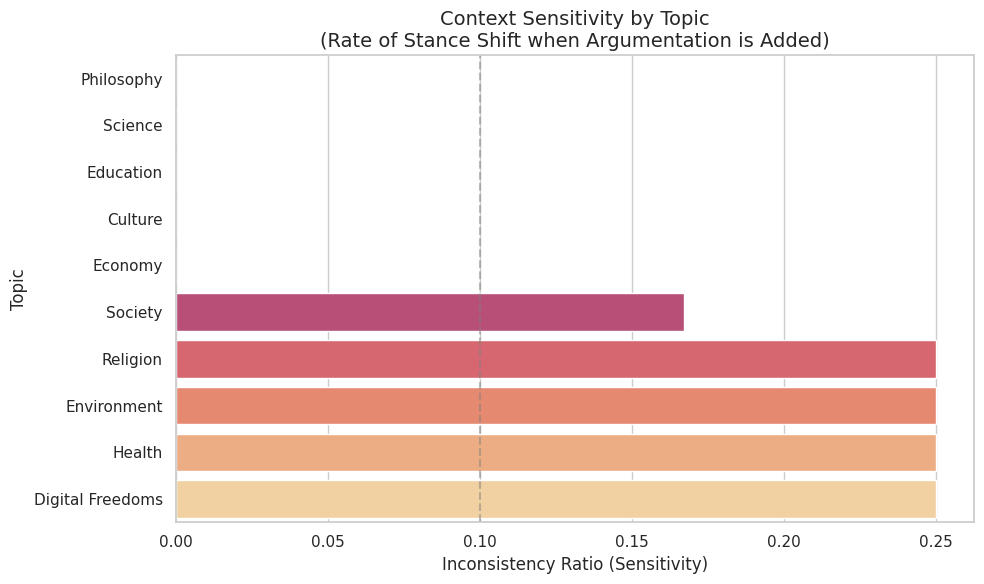

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


data = {
    'Digital Freedoms': 0.25, 'Environment': 0.25, 'Religion': 0.25, 'Philosophy': 0,
    'Science': 0, 'Health': 0.25, 'Society': 0.167,
    'Education': 0.0, 'Culture': 0.0, 'Economy': 0.0
}


df_plot = pd.DataFrame(list(data.items()), columns=['Topic', 'Inconsistency Ratio'])
df_plot = df_plot.sort_values('Inconsistency Ratio', ascending=True) #

plt.figure(figsize=(10, 6))

sns.barplot(x='Inconsistency Ratio', y='Topic', data=df_plot, palette='magma')

plt.title('Context Sensitivity by Topic\n(Rate of Stance Shift when Argumentation is Added)', fontsize=14)
plt.xlabel('Inconsistency Ratio (Sensitivity)', fontsize=12)
plt.ylabel('Topic', fontsize=12)
plt.axvline(x=0.1, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Source of Variance: Topic-Driven or Persona-Driven

Inter-Persona Divergence
Inter-Topic Divergence

/usr/local/lib/python3.12/dist-packages/sentence_transformers/util/tensor.py:28: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  a = torch.tensor(a)



--- Variance Analysis Results ---
Avg Distance between Personas: 0.5244
Avg Distance between Topics:   0.6461
Conclusion: Topic-Driven


/tmp/ipython-input-327473549.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='inter_persona_distance', y='topic', data=inter_persona_sorted, palette='magma')


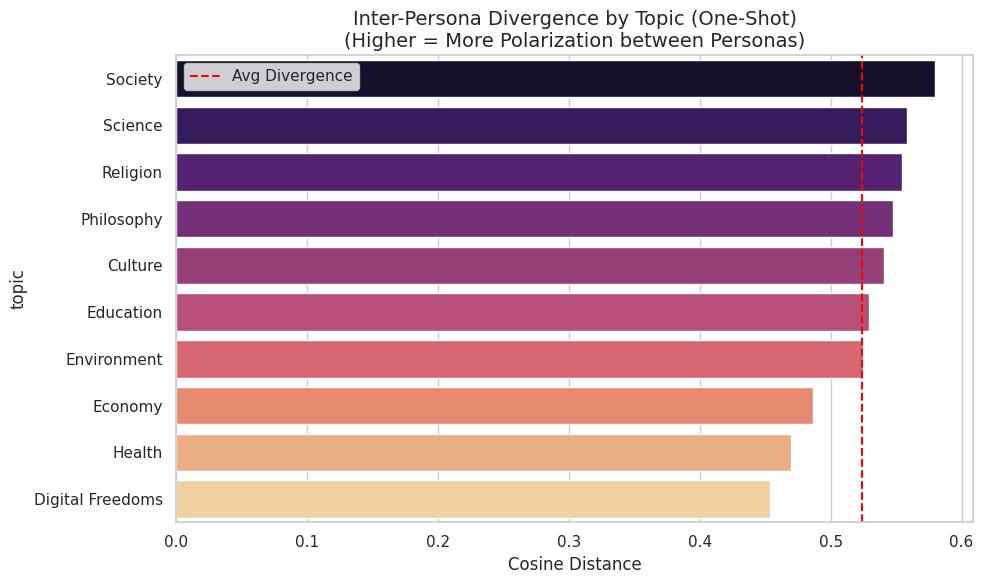

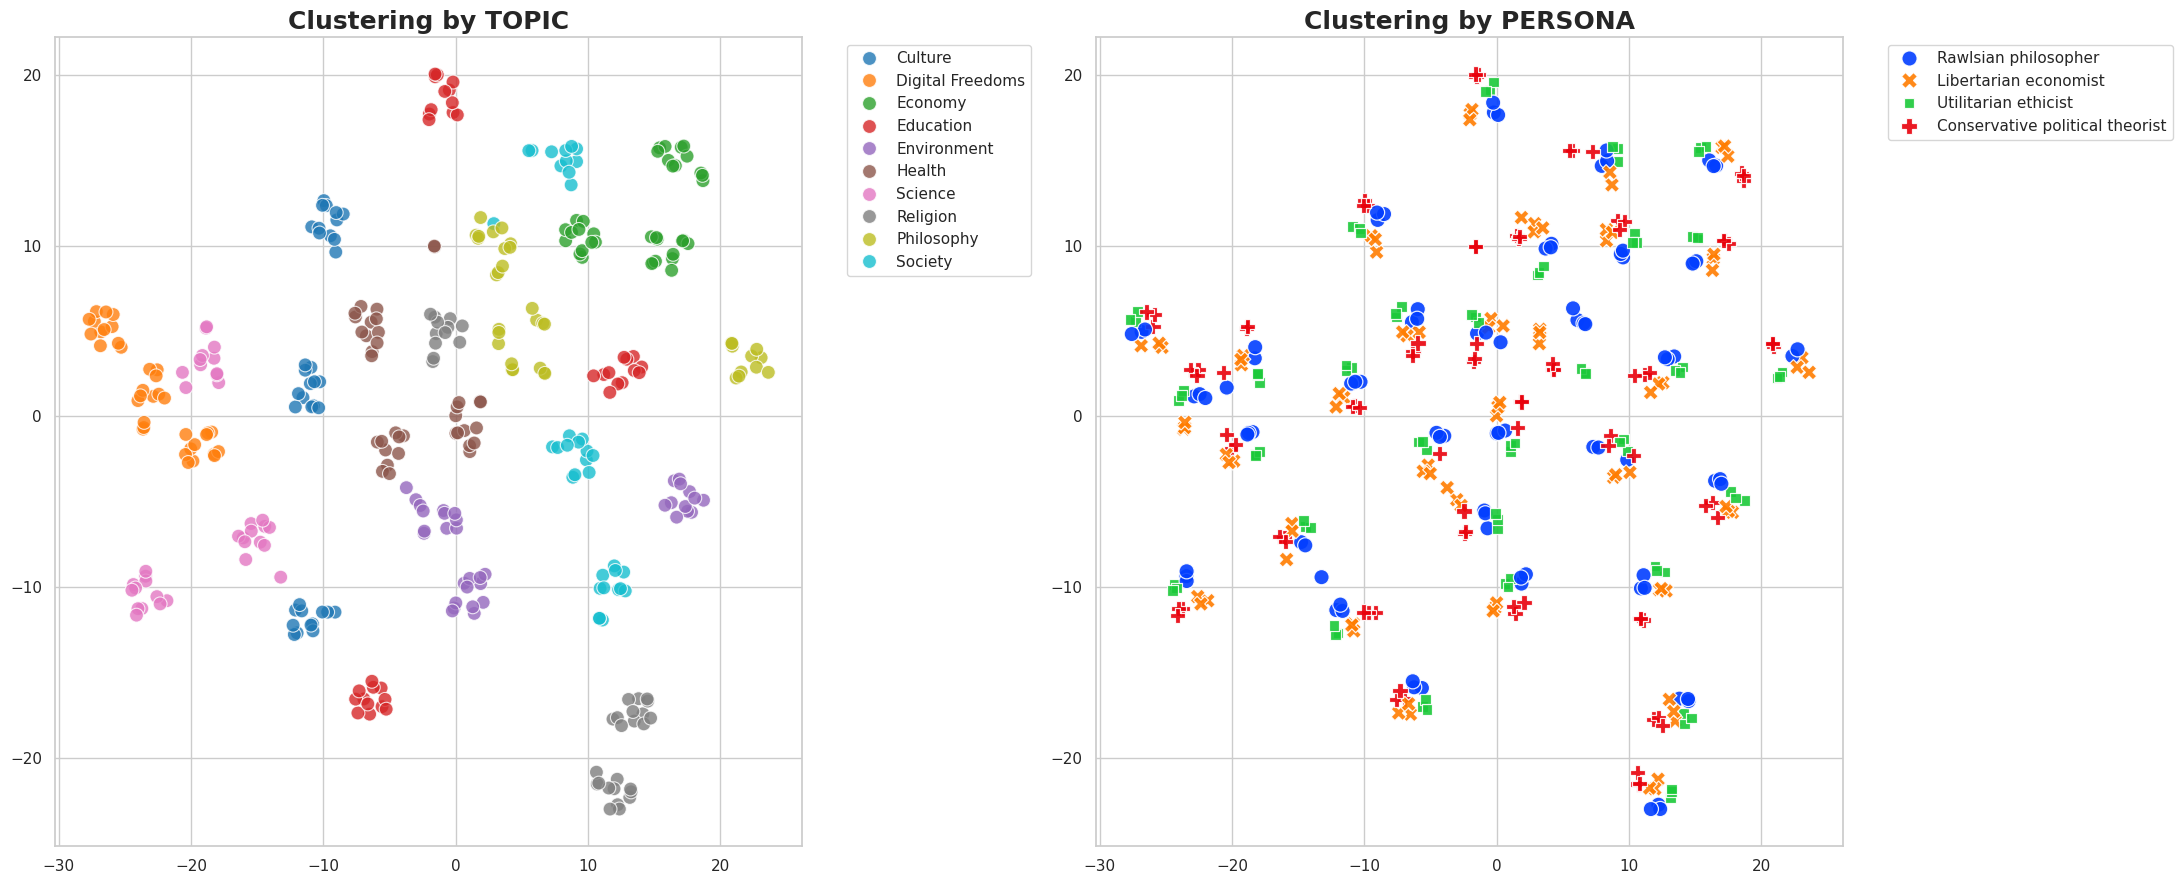

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer, util
from sklearn.manifold import TSNE
import torch

def ensure_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.cpu().detach().numpy()
    return x

df_one_shot['embedding'] = df_one_shot['embedding'].apply(ensure_numpy)


topics = ["Culture", "Digital Freedoms", "Economy", "Education", "Environment",
          "Health", "Science", "Religion", "Philosophy", "Society"]
topic_mapping = []
for t in topics:
    topic_mapping.extend([t]*3)

df_topic = pd.DataFrame({'index': range(1, 31), 'topic': topic_mapping})

if 'topic' not in df_one_shot.columns:
    df_one_shot = df_one_shot.merge(df_topic, on='index', how='left')


def calculate_pairwise_divergence(embeddings):

    if len(embeddings) < 2: return 0

    sim_matrix = util.cos_sim(embeddings, embeddings)

    distances = []
    rows, cols = sim_matrix.shape
    for r in range(rows):
        for c in range(r + 1, cols):
            distances.append(1 - sim_matrix[r][c].item())

    return np.mean(distances)


# 指标 A: 同一个 Topic 下，不同 Persona 的距离
metric_persona_div = df_one_shot.groupby('topic')['embedding'].apply(
    lambda x: calculate_pairwise_divergence(list(x))
).reset_index(name='inter_persona_distance')
metric_persona_div['type'] = 'Between Personas (Same Topic)'

# 指标 B: 同一个 Persona 下，不同 Topic 的距离
metric_topic_div = df_one_shot.groupby('persona')['embedding'].apply(
    lambda x: calculate_pairwise_divergence(list(x))
).reset_index(name='inter_topic_distance')
metric_topic_div = metric_topic_div.rename(columns={'inter_topic_distance': 'distance'})
metric_topic_div['type'] = 'Between Topics (Same Persona)'


mean_persona_div = metric_persona_div['inter_persona_distance'].mean()
mean_topic_div = metric_topic_div['distance'].mean()

print("\n--- Variance Analysis Results ---")
print(f"Avg Distance between Personas: {mean_persona_div:.4f}")
print(f"Avg Distance between Topics:   {mean_topic_div:.4f}")

if mean_topic_div > mean_persona_div:
    print("Conclusion: Topic-Driven")
else:
    print("Conclusion: Persona-Driven")


inter_persona_sorted = metric_persona_div.sort_values('inter_persona_distance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='inter_persona_distance', y='topic', data=inter_persona_sorted, palette='magma')
plt.title('Inter-Persona Divergence by Topic (One-Shot)\n(Higher = More Polarization between Personas)', fontsize=14)
plt.xlabel('Cosine Distance', fontsize=12)
plt.axvline(x=mean_persona_div, color='red', linestyle='--', label='Avg Divergence')
plt.legend()
plt.tight_layout()
plt.show()


matrix = np.stack(df_one_shot['embedding'].values)
topic_labels = df_one_shot['topic'].tolist()
persona_labels = df_one_shot['persona'].tolist()

tsne = TSNE(n_components=2, random_state=42, perplexity=30, init='pca', learning_rate='auto')
projections = tsne.fit_transform(matrix)

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

# topic
sns.scatterplot(
    x=projections[:, 0], y=projections[:, 1],
    hue=topic_labels, palette='tab10', s=100, alpha=0.8, ax=axes[0]
)
axes[0].set_title('Clustering by TOPIC', fontsize=18, fontweight='bold')
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# persona
sns.scatterplot(
    x=projections[:, 0], y=projections[:, 1],
    hue=persona_labels, style=persona_labels,
    palette='bright', s=120, alpha=0.9, ax=axes[1]
)
axes[1].set_title('Clustering by PERSONA', fontsize=18, fontweight='bold')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

6. LLM-as-a-judge
Recognizability Test

In [ ]:
!pip install groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 5.9 MB/s eta 0:00:00


In [ ]:
import json
import re
import time
import pandas as pd
from groq import Groq

# --- 1. 配置区域 ---
# 请替换为你的 API Key
client = Groq(api_key="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")
MODEL_ID = "llama-3.1-8b-instant" # 推荐用这个，指令跟随能力强

# 定义人设及其核心特征 (帮助模型区分，防止瞎猜)
PERSONA_DEFINITIONS = {
    "Rawlsian philosopher",
    "Libertarian economist",
    "Utilitarian ethicist",
    "Conservative political theorist"
}



# --- 2. 增强的数据加载函数 ---
def extract_arguments(json_file):
    with open(json_file, "r", encoding="utf-8") as f:
        data = json.load(f)

    rows = []
    for item in data:
        response_text = item.get("response", "")

        # 尝试提取 Argument 之后的内容
        # 兼容 Markdown 加粗 (**Argument:**) 和普通写法
        match = re.search(r"(?:\*\*|)?Argument:(?:\*\*|)?\s*(.*)", response_text, re.DOTALL | re.IGNORECASE)

        if match and len(match.group(1).strip()) > 10:
            argument = match.group(1).strip()
        else:
            # 【关键修改】如果正则没提取到，或者提取内容太短，直接使用全文！
            # 这样保证模型一定有东西看，不会因为输入为空而产生幻觉
            argument = response_text.strip()

        rows.append({
            "index": item.get("index"),
            "true_persona": item.get("persona"), # 记录真实人设用于对比
            "argument_text": argument
        })

    return pd.DataFrame(rows)

# --- 3. 优化的分类函数 (Prompt Engineering) ---
def classify_persona(argument_text):
    # 如果文本实在太短，直接跳过，省钱
    if len(argument_text) < 5:
        return "Error: Text Empty"

    # 【关键修改】优化 Prompt：加入定义，移除列表顺序的干扰
    prompt = f"""
Role: You are an expert analyst of political philosophy.

Task: Analyze the following text and determine which persona wrote it.

Candidates:
- Rawlsian philosopher
- Libertarian economist
- Utilitarian ethicist
- Conservative political theorist

Input Text:
"{argument_text[:2500]}"

Instructions:
1. Ignore the phrase "As a..." if present.
2. Analyze the reasoning logic.
3. Return ONLY the exact persona name from the list above. No explanation.
"""

    try:
        response = client.chat.completions.create(
            model=MODEL_ID,
            messages=[{"role": "user", "content": prompt}],
            temperature=0.0, # 必须是0，保证确定性
            max_tokens=20
        )
        result = response.choices[0].message.content.strip()

        # 清洗结果，防止模型多说话
        for p in PERSONA_NAMES:
            if p.lower() in result.lower():
                return p
        return "Unknown"

    except Exception as e:
        print(f"API Error: {e}")
        return "Error"

# --- 4. 执行主流程 ---

# 1. 加载数据
file_path = "/content/drive/MyDrive/masterthesis/glm-3-turbo/one-shot/Claim_only__one_shot_output.json"
print("Loading data...")
df = extract_arguments(file_path)
print(f"Loaded {len(df)} rows.")

# 2. 打印一条看看输入是不是正常的 (Debug)
print(f"\n[Debug] Sample Input Text (Index {df.iloc[0]['index']}):")
print(f"{df.iloc[0]['argument_text'][:150]}...\n")

# 3. 开始分类 (为了省 Token，你可以先只跑前 10 个测试一下效果)
# 如果想跑全量，把 .head(10) 去掉
print("Starting classification...")

predicted_personas = []
# df_subset = df.head(20) # <--- 先跑20个试试！确认没问题再跑全量
df_subset = df # <--- 这里跑全量

for idx, row in df_subset.iterrows():
    pred = classify_persona(row['argument_text'])
    predicted_personas.append(pred)

    # 打印进度对比，看看是不是都在变
    print(f"Index {row['index']} | True: {row['true_persona'].split()[0]} -> Pred: {pred}")

    time.sleep(0.5) # 防止速率限制

# 4. 保存结果
df_subset['predicted_persona'] = predicted_personas
output_file = "classification_results_claim_only.csv"
df_subset.to_csv(output_file, index=False)
print(f"\nDone! Results saved to {output_file}")

# 5. 简单统计一下分布，看是不是全是 Rawlsian
print("\n--- Prediction Distribution ---")
print(df_subset['predicted_persona'].value_counts())


Loading data...
Loaded 120 rows.

[Debug] Sample Input Text (Index 1):
Access to cultural institutions is a fundamental component of fair equality of opportunity, as it enriches the moral and intellectual development of a...

Starting classification...
API Error: name 'PERSONA_NAMES' is not defined
Index 1 | True: Rawlsian -> Pred: Error
API Error: name 'PERSONA_NAMES' is not defined
Index 1 | True: Libertarian -> Pred: Error
API Error: name 'PERSONA_NAMES' is not defined
Index 1 | True: Utilitarian -> Pred: Error
API Error: name 'PERSONA_NAMES' is not defined
Index 1 | True: Conservative -> Pred: Error
API Error: name 'PERSONA_NAMES' is not defined
Index 2 | True: Rawlsian -> Pred: Error
API Error: name 'PERSONA_NAMES' is not defined
Index 2 | True: Libertarian -> Pred: Error
API Error: name 'PERSONA_NAMES' is not defined
Index 2 | True: Utilitarian -> Pred: Error
API Error: name 'PERSONA_NAMES' is not defined
Index 2 | True: Conservative -> Pred: Error
API Error: name 'PERSONA_NAMES'

KeyboardInterrupt: 

In [ ]:
import json
import re
import time
import pandas as pd
from groq import Groq

# --- 1. Configuration ---
# REPLACE with your actual API Key
client = Groq(api_key="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")

# Using the fast model for efficiency.
# If accuracy is low, switch to "llama-3.3-70b-versatile"
MODEL_ID = "llama-3.1-8b-instant"

PERSONA_NAMES = [
    "Rawlsian philosopher",
    "Libertarian economist",
    "Utilitarian ethicist",
    "Conservative political theorist"
]

# --- 2. Data Extraction Function ---
def extract_arguments(json_file):
    with open(json_file, "r", encoding="utf-8") as f:
        data = json.load(f)

    rows = []
    for item in data:
        response_text = item.get("response", "")

        # Regex to capture content after "Argument:" (handles Markdown bolding too)
        match = re.search(r"(?:\*\*|)?Argument:(?:\*\*|)?\s*(.*)", response_text, re.DOTALL | re.IGNORECASE)

        if match and len(match.group(1).strip()) > 10:
            argument = match.group(1).strip()
        else:
            # Fallback: use the entire response if regex fails
            argument = response_text.strip()

        rows.append({
            "index": item.get("index"),
            "true_persona": item.get("persona"),
            "argument_text": argument
        })

    return pd.DataFrame(rows)

# --- 3. Classification Function (Blind Test) ---
def classify_persona(argument_text):
    if len(argument_text) < 5:
        return "Error: Text Empty"

    # Blind Test Prompt: No feature definitions provided, only names.
    prompt = f"""
Role: You are an expert analyst of political philosophy.

Task: Analyze the following text and determine which persona wrote it.

Candidates:
- Rawlsian philosopher
- Libertarian economist
- Utilitarian ethicist
- Conservative political theorist

Input Text:
"{argument_text[:2500]}"

Instructions:
1. Ignore the phrase "As a..." if present.
2. Analyze the reasoning logic.
3. Return ONLY the exact persona name from the list above. No explanation.
"""

    try:
        response = client.chat.completions.create(
            model=MODEL_ID,
            messages=[{"role": "user", "content": prompt}],
            temperature=0.0,
            max_tokens=20
        )
        result = response.choices[0].message.content.strip()

        # Match result against the predefined list
        for p in PERSONA_NAMES:
            if p.lower() in result.lower():
                return p
        return "Unknown"

    except Exception as e:
        print(f"API Error: {e}")
        time.sleep(2) # Pause on error
        return "Error"

# --- 4. Main Execution ---

# 1. Load Data
file_path = "/content/drive/MyDrive/masterthesis/glm-3-turbo/one-shot/Claim_only__one_shot_output.json"
print("Loading data...")
df = extract_arguments(file_path)
print(f"Loaded {len(df)} rows.")

# 2. Debug: Print first sample to ensure input is correct
print(f"\n[Debug] Sample Input Text (Index {df.iloc[0]['index']}):")
print(f"{df.iloc[0]['argument_text'][:100]}...\n")

# 3. Start Classification
print(f"Starting classification using {MODEL_ID}...")

predicted_personas = []
df_subset = df # Process all rows

for idx, row in df_subset.iterrows():
    pred = classify_persona(row['argument_text'])
    predicted_personas.append(pred)

    # Print progress
    print(f"Index {row['index']} | True: {row['true_persona'].split()[0]} -> Pred: {pred}")

    # Short delay for rate limits (8b model is fast)
    time.sleep(0.3)

# 4. Save Results
df_subset['predicted_persona'] = predicted_personas
output_file = "classification_results_claim_only_blind.csv"
df_subset.to_csv(output_file, index=False)
print(f"\nDone! Results saved to {output_file}")

# 5. Print Distribution
print("\n--- Prediction Distribution ---")
print(df_subset['predicted_persona'].value_counts())

In [ ]:
df_all_classified.to_csv("/content/drive/MyDrive/masterthesis/glm-3-turbo/one-shot/persona_classification_results.csv", index=False)

# split
df_claim_only_classified = df_all_classified[df_all_classified['dataset'] == "Claim Only"]
df_claim_premise_classified = df_all_classified[df_all_classified['dataset'] == "Claim + Premise"]
df_claim_prem_arg_classified = df_all_classified[df_all_classified['dataset'] == "Claim + Premise + Argumentation"]

# save separately
df_claim_only_classified.to_csv(
    "/content/drive/MyDrive/masterthesis/glm-3-turbo/one-shot/Claim_Only_classification_results.csv",
    index=False
)

df_claim_premise_classified.to_csv(
    "/content/drive/MyDrive/masterthesis/glm-3-turbo/one-shot/Claim_Premise_classification_results.csv",
    index=False
)

df_claim_prem_arg_classified.to_csv(
    "/content/drive/MyDrive/masterthesis/glm-3-turbo/one-shot/Claim_Prem_Arg_classification_results.csv",
    index=False
)


In [ ]:
import re
import pandas as pd
from groq import Groq

# --- 0. Initialize Groq client ---
client = Groq(api_key="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")  # replace with your key
MODEL_ID = "groq/compound-mini"

# --- 1. Stance strength scoring ---
def query_stance_strength(persona, topic_statement):
    """
    Returns a numeric support score (1-10) for a given persona and topic.
    """
    prompt = f"""
You are a {persona}.

Statement: "{topic_statement}"

Question: How strongly do you support or oppose this statement?
Scale: 1 (Strongly Oppose) to 10 (Strongly Support). 5 is Neutral.

Return ONLY the number (e.g., 8). Do not write sentences.
"""
    try:
        response = client.chat.completions.create(
            model=MODEL_ID,
            messages=[{"role": "user", "content": prompt}],
            temperature=0
        )
        raw_score = response.choices[0].message.content.strip()
        match = re.search(r'\d+', raw_score)
        if match:
            score = float(match.group())
            return max(1.0, min(10.0, score))  # clamp to 1-10
        else:
            return 5.0
    except Exception as e:
        print(f"Scoring Error: {e}")
        return 5.0

# --- 2. Apply scoring to a dataframe ---
def score_stance_in_df(df):
    scores = []
    for _, row in df.iterrows():
        persona = row["persona"]  # use original persona
        topic = row["claim"] if row["claim"] else "Sample Topic Statement"
        score = query_stance_strength(persona, topic)
        scores.append(score)
    df["strength_score"] = scores
    return df

# --- 3. Run scoring on all datasets ---
df_claim_only = score_stance_in_df(df_claim_only)
df_claim_premise = score_stance_in_df(df_claim_premise)
df_claim_prem_arg = score_stance_in_df(df_claim_prem_arg)

# Optional: combine for visualization or export
df_all_scored = pd.concat([df_claim_only, df_claim_premise, df_claim_prem_arg], ignore_index=True)

# Save to CSV
df_all_scored.to_csv("stance_strength_results.csv", index=False)

# Preview
print(df_all_scored.head())


In [ ]:
output_csv_path = "/content/drive/MyDrive/masterthesis/stance_strength_results.csv"
df_results.to_csv(output_csv_path, index=False, encoding='utf-8-sig')

print(f"Analysis complete! Scores saved to: {output_csv_path}")
print(df_results[['persona', 'predicted_persona', 'strength_score']].head())